In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:

iris = load_iris()

X = iris.data
y = iris.target

# Creating DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)

# Adding target column
df['Target'] = y

# Display first 5 rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [ ]:

print("\nShape of Dataset:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Shape of Dataset:
(150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      Target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.

Feature STANDARDIZATION

In [ ]:
# Separating features
X_features = df.drop('Target', axis=1)

# Applying StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_features)

print("\nStandardized Data:")
print(X_scaled[:5])


Standardized Data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


PCA

In [ ]:

# Reducing dimensions from 4 -> 2
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Creating PCA DataFrame
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

# Adding target column
pca_df['Target'] = y

print("\nPCA Transformed Data:")
print(pca_df.head())


PCA Transformed Data:
   Principal Component 1  Principal Component 2  Target
0              -2.264703               0.480027       0
1              -2.080961              -0.674134       0
2              -2.364229              -0.341908       0
3              -2.299384              -0.597395       0
4              -2.389842               0.646835       0


Variance Ratio

In [ ]:
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Captured:")
print(sum(pca.explained_variance_ratio_))


Explained Variance Ratio:
[0.72962445 0.22850762]

Total Variance Captured:
0.9581320720000166


Scree Plot

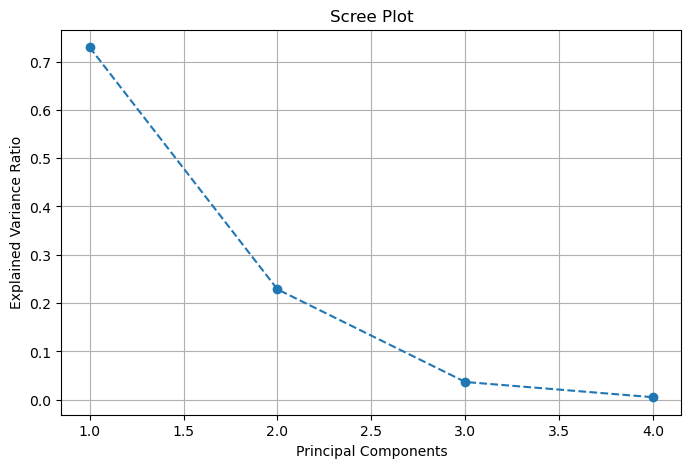

In [ ]:
# PCA with all components
pca_full = PCA()

pca_full.fit(X_scaled)

# Plotting Scree Plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker='o',
    linestyle='--'
)

plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

plt.grid(True)

plt.show()

PCA Data Visualization

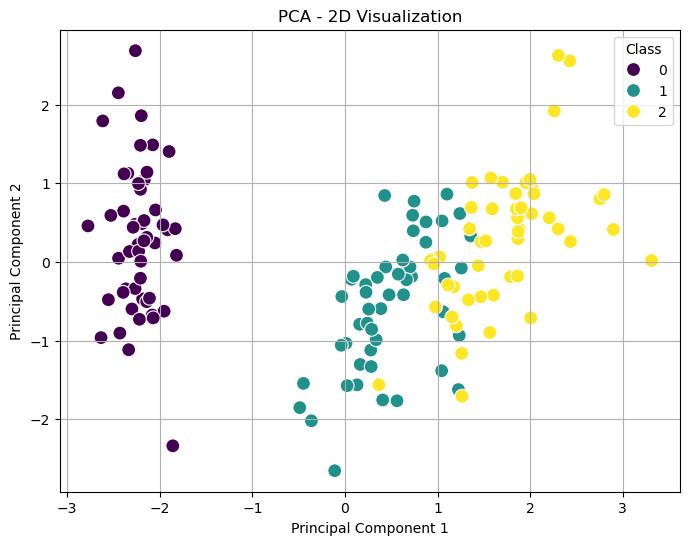

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=pca_df,
    palette='viridis',
    s=100
)

plt.title("PCA - 2D Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title='Class')

plt.grid(True)

plt.show()

pip install numpy pandas matplotlib seaborn scikit-learn